<a href="https://colab.research.google.com/github/mikhael2104/visi_komputer/blob/main/Jobsheet_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **JOBSHEET 02: KLASIFIKASI GAMBAR**

### **PRAKTIKUM SECTION**

PRAKTIKUM 1 - Memulai Klasifikasi Gambar dengan Dataset Sederhana

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


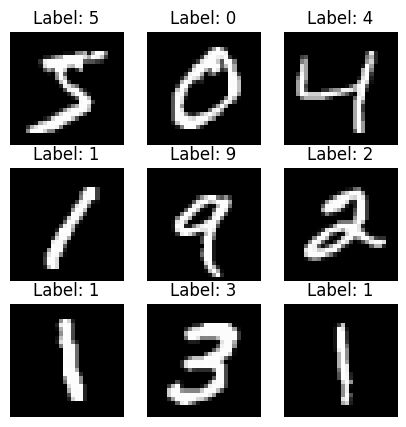

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

#Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')
plt.show()

PRAKTIKUM 2 - Klasifikasi Gambar dengan Model Machine Learning Tradisional

In [4]:
from sklearn import svm
from sklearn.metrics import accuracy_score

#Flatten
x_train_flat = x_train.reshape(len(x_train), -1)/255.0
x_test_flat = x_test.reshape(len(x_test), -1)/255.0

#SVM
clf = svm.SVC(kernel='linear', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000])
y_pred = clf.predict(x_test_flat)

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9101


PRAKTIKUM 3 - Membangun CNN Sederhana

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.9401 - loss: 0.2054 - val_accuracy: 0.9813 - val_loss: 0.0772
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.9806 - loss: 0.0663 - val_accuracy: 0.9855 - val_loss: 0.0539
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9864 - loss: 0.0456 - val_accuracy: 0.9857 - val_loss: 0.0507
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 29ms/step - accuracy: 0.9893 - loss: 0.0345 - val_accuracy: 0.9873 - val_loss: 0.0525
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9925 - loss: 0.0250 - val_accuracy: 0.9860 - val_loss: 0.0527


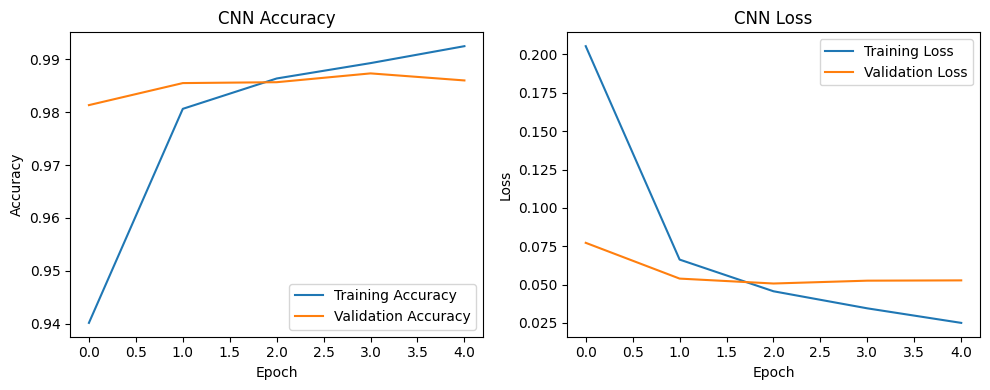

In [5]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Reshape data ke format (batch, height, width, channels)
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

# 2. Bangun arsitektur CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

# 3. Kompilasi dan pelatihan
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    x_train_cnn, y_train, epochs=5, validation_split=0.1, batch_size=64
)

# 4. Plot riwayat pelatihan
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

PRAKTIKUM 4 - Eksperimen dengan Dataset lebih Kompleks

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 41ms/step - accuracy: 0.4601 - loss: 1.5043 - val_accuracy: 0.5566 - val_loss: 1.2424
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 60s 42ms/step - accuracy: 0.5989 - loss: 1.1489 - val_accuracy: 0.6326 - val_loss: 1.0663
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 76s 38ms/step - accuracy: 0.6420 - loss: 1.0314 - val_accuracy: 0.6486 - val_loss: 1.0160
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 39ms/step - accuracy: 0.6697 - loss: 0.9505 - val_accuracy: 0.6684 - val_loss: 0.9775
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.6930 - loss: 0.8899 - val_accuracy: 0.6614 - val_loss: 0.9732
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.7101 - loss: 0.8344 - val_accuracy: 0.6816 - val_loss: 0.9267
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.7282 - loss: 0.7838 - val_accuracy: 0.6810 - val_loss: 0.9286
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.7430 -

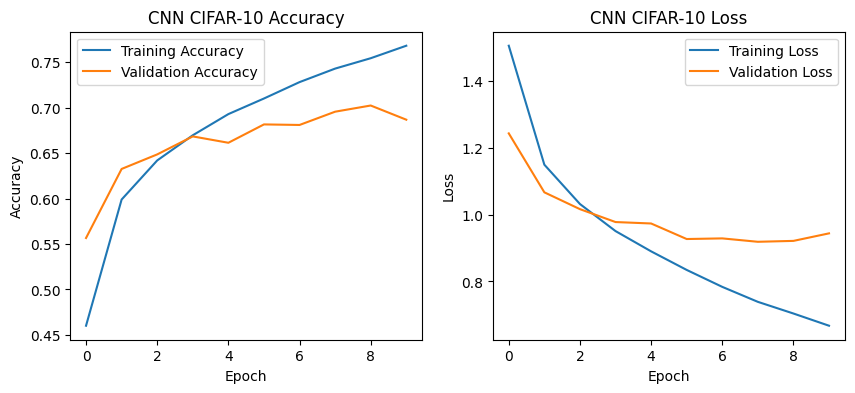

In [6]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

#===== Plot history =====
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

PRAKTIKUM 5 - Transfer Learning dengan Model Pra-Latih

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 587s 415ms/step - accuracy: 0.5184 - loss: 1.3816 - val_accuracy: 0.5760 - val_loss: 1.2137
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 550s 391ms/step - accuracy: 0.5808 - loss: 1.1963 - val_accuracy: 0.5868 - val_loss: 1.1781
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 584s 406ms/step - accuracy: 0.6020 - loss: 1.1420 - val_accuracy: 0.5978 - val_loss: 1.1555
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 543s 386ms/step - accuracy: 0.6144 - loss: 1.0987 - val_accuracy: 0.6132 - val_loss: 1.1136
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 559s 384ms/step - accuracy: 0.6262 - loss: 1.0665 - val_accuracy: 0.6172 - val_loss: 1.1134


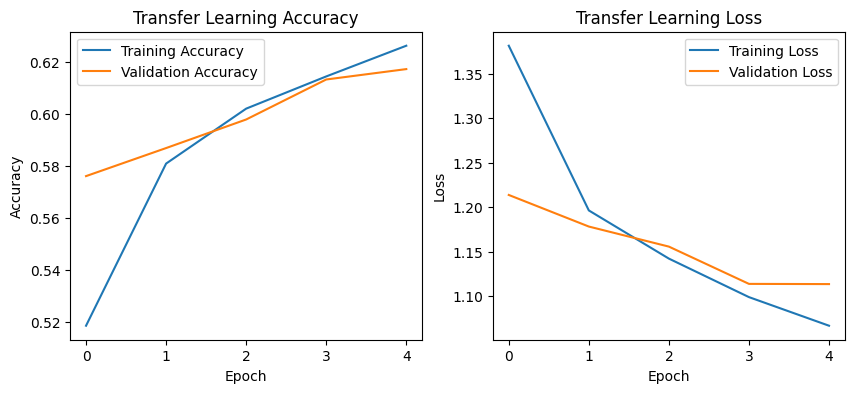

In [9]:
from tensorflow.keras.applications import VGG16
base_model = VGG16(weights='imagenet', include_top=False,
input_shape=(32,32,3))
base_model.trainable = False
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

PRAKTIKUM 6 - Evaluasi dengan Confusion Matrix dan Metrik Lain

313/313 ━━━━━━━━━━━━━━━━━━━━ 108s 346ms/step
              precision    recall  f1-score   support

           0       0.65      0.70      0.68      1000
           1       0.62      0.72      0.67      1000
           2       0.51      0.49      0.50      1000
           3       0.49      0.37      0.42      1000
           4       0.53      0.54      0.54      1000
           5       0.60      0.49      0.54      1000
           6       0.55      0.74      0.63      1000
           7       0.66      0.65      0.66      1000
           8       0.76      0.66      0.70      1000
           9       0.60      0.62      0.61      1000

    accuracy                           0.60     10000
   macro avg       0.60      0.60      0.59     10000
weighted avg       0.60      0.60      0.59     10000



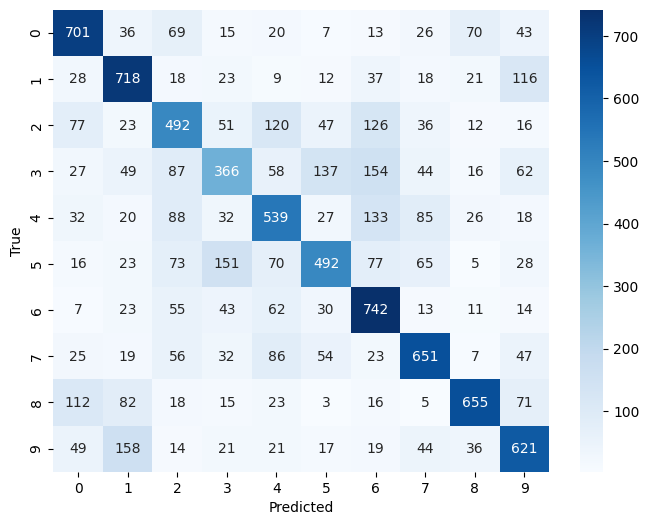

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test).argmax(axis=1)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### **PENUGASAN SECTION**